# Reproduce a published result with ScreamingFace

Reproduce the results obtained by OpenRouter, but for live reasons, we use **DRACO Lite**, a small version of DRACO (one case, ten criteria, one judge pass).

### The engine

Everything runs through the **ScreamingFace engine**, a small service you run locally.

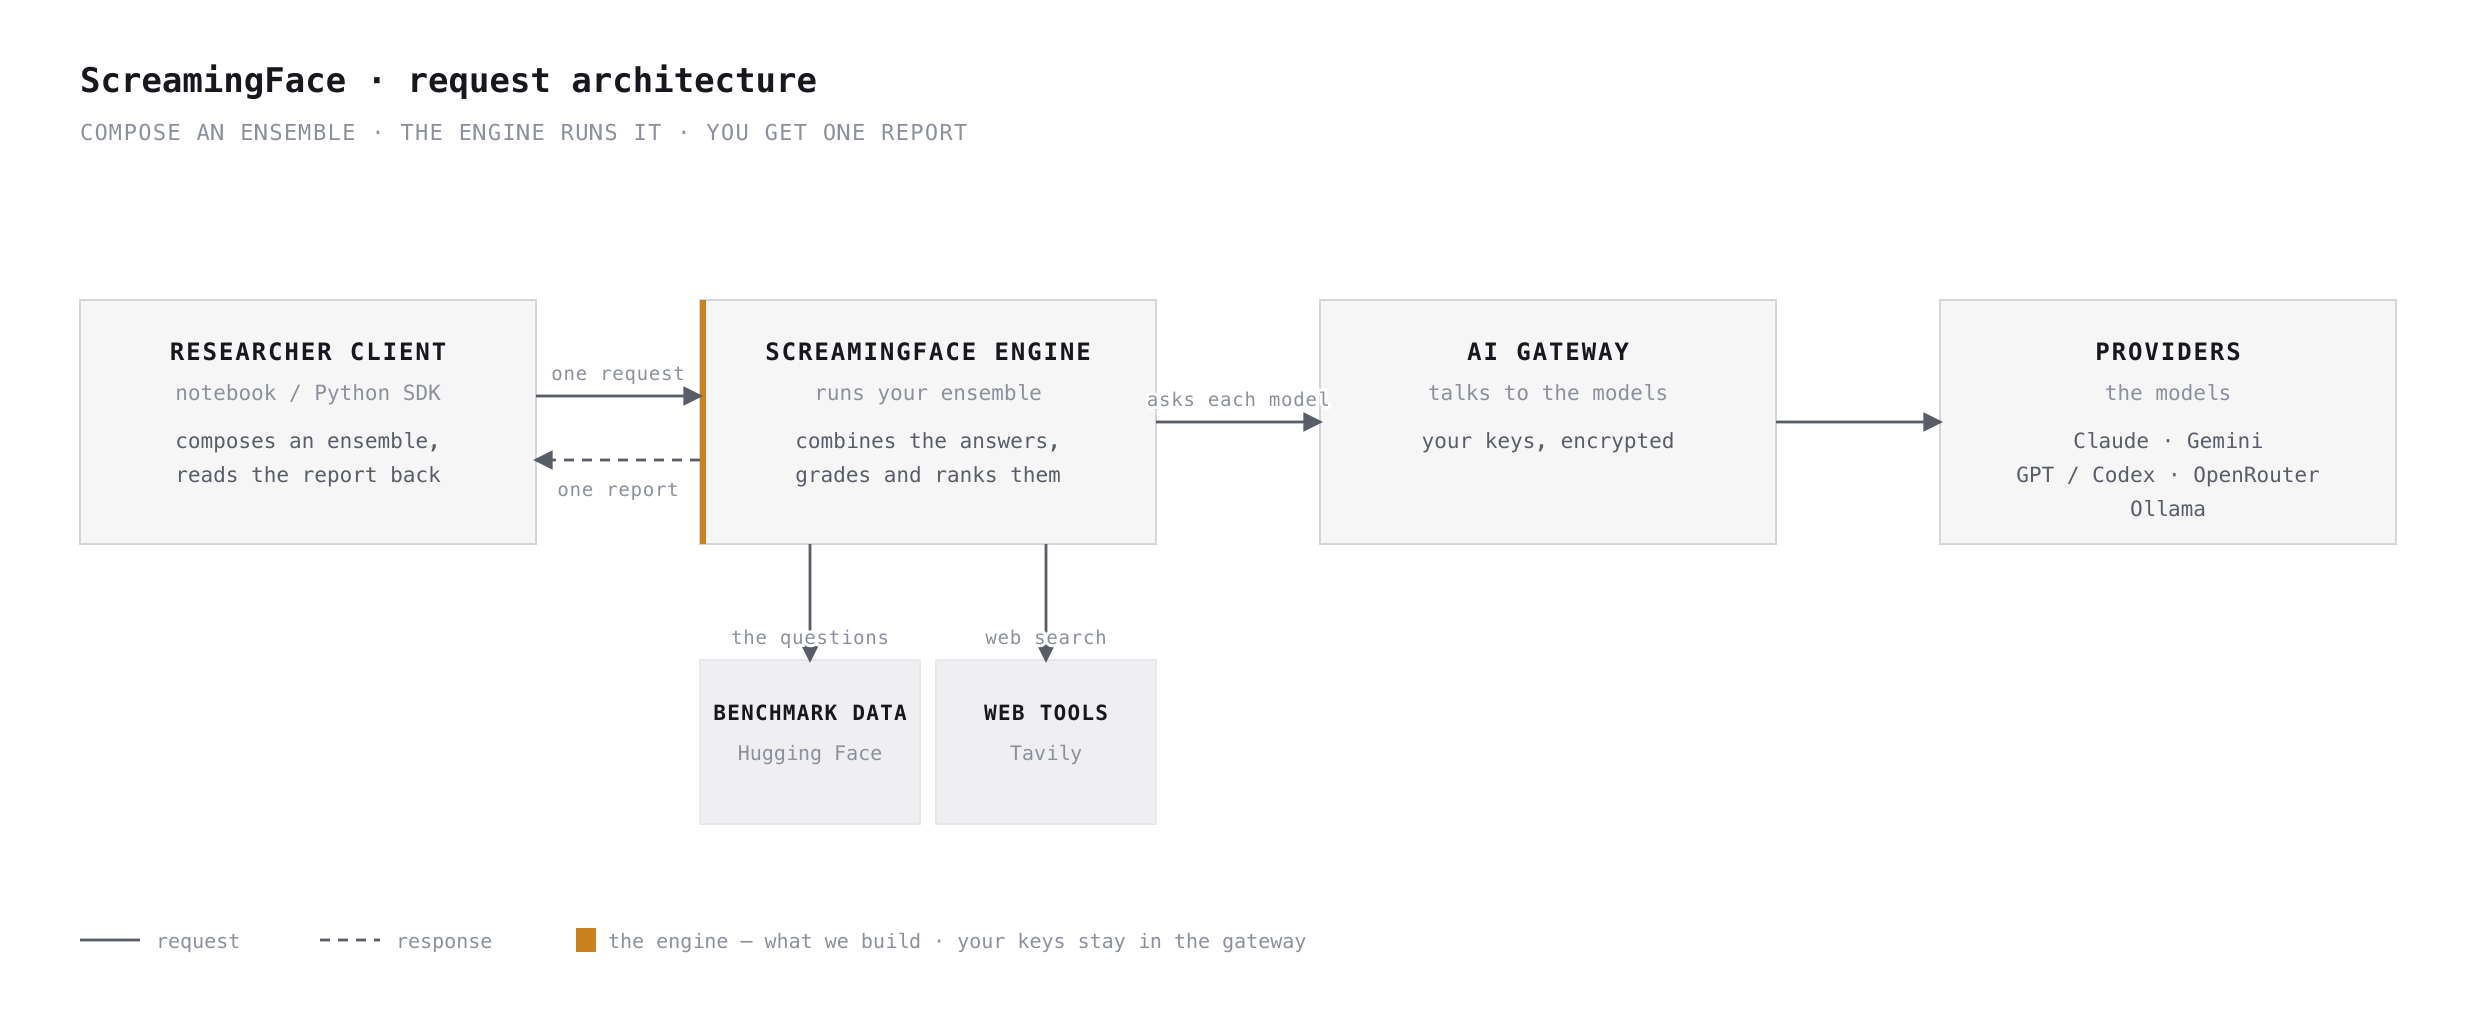


- **What it does.** You describe an ensemble. The engine asks each model your question, merges the
  answers into one, grades it against the benchmark, and hands back a single report.
- **Many providers.** Claude, Gemini, GPT / Codex, OpenRouter, Ollama — one API.
- **Your keys stay yours.** Credentials go only to your engine; the SDK never sees them.
- **Subsidized compute is coming** (Wave 1), so you can run without spending your own budget.

## Quick Start — reproduce a result in four steps

Start the local stack first — `packages/screamingface/apps/screamingface-engine/dev.sh` with an
accepted `HF_TOKEN` in its `.env` — then connect a provider in the panel below. Benchmark and model
discovery come from the engine's registry; there is no client-side fallback.

In [1]:
import screamingface as sf

sf.connect()

PanelWidget(children=(HTML(value='<style>\n@import url(\'https://fonts.googleapis.com/css2?family=IBM+Plex+Mon…

The panel sends credentials only to the configured engine and shows the engine origin before
you act. Connect the providers you plan to use — here, OpenRouter.

In [2]:
sf.models.view()

### Step 1 · Load the benchmark

`load` reads the benchmark manifest the engine advertises — its grader, aggregator, judge passes,
and tool policy. It does not download cases; the engine loads the pinned dataset revision at run
time.

In [3]:
draco = sf.benchmarks.load("draco-lite@1")

draco

Benchmark(id='draco-lite@1', title='DRACO Lite', grader=Rubric(model='openrouter/google/gemini-3.1-pro-preview', prompt='You are evaluating a response for a given query against a single criterion.\n\nYou will receive the response to evaluate, a single criterion to check, and a <criterion_type> field indicating if the criterion is positive or negative.\n\nCRITERION TYPES:\nThe <criterion_type> field tells you whether this criterion describes something desirable (positive) or undesirable (negative). Your job is THE SAME for both types: determine if the thing described in the criterion is actually present in the response.\n\nPOSITIVE CRITERIA:\nPositive criteria describe desired traits, requirements, or content that should be present.\n- MET (criterion_status: "MET"): The response contains/satisfies the requirement\n- UNMET (criterion_status: "UNMET"): The response does not contain/satisfy the requirement\n\nNEGATIVE CRITERIA:\nNegative criteria describe active errors or mistakes that the response is making.\n- MET (criterion_status: "MET"): The response advocates, states, or recommends the problematic thing\n- UNMET (criterion_status: "UNMET"): The response does NOT make this error, OR it mentions the thing only to warn against it or mention why it\'s wrong\n\nExamples of what does NOT count as MET for negative criteria:\n- "This is often misdiagnosed as X, but it\'s actually Y" → NOT stating it\'s X (UNMET)\n- "Avoid doing X because..." → NOT recommending X (UNMET)\n- "Unlike X, the correct approach is Y" → NOT advocating for X (UNMET)\n- "A common mistake is thinking X" → NOT claiming X is correct (UNMET)\n\nEVALUATION RULES:\n- For numerical values: Check if they fall within specified ranges or match exactly as required.\n- For factual claims: Verify the information is present and accurate, regardless of exact phrasing.\n- For required elements: Confirm presence, counting precisely when numbers are specified.\n- For exclusion requirements: Confirm that restricted content is absent.\n- For length requirements: Carefully measure the number of words, characters, items, etc.\n- Be strict about factual accuracy but flexible about wording.\n- Accept semantically equivalent statements or implications where appropriate.\n- Pay careful attention to negation, warnings, and contrasts.\n\nCONDITIONAL VS UNCONDITIONAL ACTIONS (CRITICAL):\nWhen a criterion requires an action to be done "immediately", "now", "as soon as possible", or unconditionally, you must distinguish:\n- UNCONDITIONAL: "Give epinephrine now" or "Administer X immediately" → action IS being taken\n- CONDITIONAL: "If Y occurs, give epinephrine" or "Start X if condition Z" → action is NOT being taken immediately; it\'s contingent on a future condition\n\nIf the criterion says something should happen "immediately" or without conditions, a conditional statement does NOT satisfy the criterion. Mark as UNMET.\n\nExample:\n- Criterion: "Administers alteplase immediately for acute ischemic stroke"\n- Output: "If CT confirms no hemorrhage, consider alteplase" → UNMET (conditional, not immediate)\n- Output: "Give alteplase now per acute stroke protocol" → MET (immediate, unconditional)\n\nIMPLICIT VS EXPLICIT SATISFACTION:\nConsider whether a criterion can be satisfied implicitly through context, tone, or logical implication, not just explicit statements:\n- "States there is no location in China" can be MET by "Locations are only in United States and Canada"—if locations are ONLY in US and Canada, China is excluded; no need to mention China\n- "Confirms the user is logged out" can be MET by "Session expired at 3:42 PM"—an expired session means the user is logged out, even without stating it directly\n\nCRITERION STATUS:\n"criterion_status" has *nothing* to do with quality or correctness. It only means:\n- "MET": The thing described in the criterion IS present/occurring in the response\n- "UNMET": The thing described in the criterion IS NOT present/occurring in the response\n\nYour 

In [4]:
draco.grader

Rubric(model='openrouter/google/gemini-3.1-pro-preview', prompt='You are evaluating a response for a given query against a single criterion.\n\nYou will receive the response to evaluate, a single criterion to check, and a <criterion_type> field indicating if the criterion is positive or negative.\n\nCRITERION TYPES:\nThe <criterion_type> field tells you whether this criterion describes something desirable (positive) or undesirable (negative). Your job is THE SAME for both types: determine if the thing described in the criterion is actually present in the response.\n\nPOSITIVE CRITERIA:\nPositive criteria describe desired traits, requirements, or content that should be present.\n- MET (criterion_status: "MET"): The response contains/satisfies the requirement\n- UNMET (criterion_status: "UNMET"): The response does not contain/satisfy the requirement\n\nNEGATIVE CRITERIA:\nNegative criteria describe active errors or mistakes that the response is making.\n- MET (criterion_status: "MET"): The response advocates, states, or recommends the problematic thing\n- UNMET (criterion_status: "UNMET"): The response does NOT make this error, OR it mentions the thing only to warn against it or mention why it\'s wrong\n\nExamples of what does NOT count as MET for negative criteria:\n- "This is often misdiagnosed as X, but it\'s actually Y" → NOT stating it\'s X (UNMET)\n- "Avoid doing X because..." → NOT recommending X (UNMET)\n- "Unlike X, the correct approach is Y" → NOT advocating for X (UNMET)\n- "A common mistake is thinking X" → NOT claiming X is correct (UNMET)\n\nEVALUATION RULES:\n- For numerical values: Check if they fall within specified ranges or match exactly as required.\n- For factual claims: Verify the information is present and accurate, regardless of exact phrasing.\n- For required elements: Confirm presence, counting precisely when numbers are specified.\n- For exclusion requirements: Confirm that restricted content is absent.\n- For length requirements: Carefully measure the number of words, characters, items, etc.\n- Be strict about factual accuracy but flexible about wording.\n- Accept semantically equivalent statements or implications where appropriate.\n- Pay careful attention to negation, warnings, and contrasts.\n\nCONDITIONAL VS UNCONDITIONAL ACTIONS (CRITICAL):\nWhen a criterion requires an action to be done "immediately", "now", "as soon as possible", or unconditionally, you must distinguish:\n- UNCONDITIONAL: "Give epinephrine now" or "Administer X immediately" → action IS being taken\n- CONDITIONAL: "If Y occurs, give epinephrine" or "Start X if condition Z" → action is NOT being taken immediately; it\'s contingent on a future condition\n\nIf the criterion says something should happen "immediately" or without conditions, a conditional statement does NOT satisfy the criterion. Mark as UNMET.\n\nExample:\n- Criterion: "Administers alteplase immediately for acute ischemic stroke"\n- Output: "If CT confirms no hemorrhage, consider alteplase" → UNMET (conditional, not immediate)\n- Output: "Give alteplase now per acute stroke protocol" → MET (immediate, unconditional)\n\nIMPLICIT VS EXPLICIT SATISFACTION:\nConsider whether a criterion can be satisfied implicitly through context, tone, or logical implication, not just explicit statements:\n- "States there is no location in China" can be MET by "Locations are only in United States and Canada"—if locations are ONLY in US and Canada, China is excluded; no need to mention China\n- "Confirms the user is logged out" can be MET by "Session expired at 3:42 PM"—an expired session means the user is logged out, even without stating it directly\n\nCRITERION STATUS:\n"criterion_status" has *nothing* to do with quality or correctness. It only means:\n- "MET": The thing described in the criterion IS present/occurring in the response\n- "UNMET": The thing described in the criterion IS NOT present/occurring in the response\n\nYour response must be valid JSON with this exact format:\n\n{

In [5]:
sf.benchmarks.view()

### Step 2 · Compose one Fusion

Combine three frontier models and reduce them with a synthesis model. Construction is local — no
model is called yet.

In [6]:
DRACO_ANSWER_PROMPT = """You are answering a research-quality prompt.
Provide a thorough, well-reasoned answer in prose. Address every aspect the prompt raises.
Use clear structure
(headings, bullet lists where appropriate) and cite specific facts, methodologies, or sources
where relevant.

Do not refuse, abstain, or claim uncertainty unless the question is genuinely ambiguous — the
goal is to demonstrate depth of understanding. Length: aim for the level of detail the question
warrants; brevity that skips key points will be penalised by the rubric."""

DRACO_SYNTHESIS_PROMPT = """You are synthesising a single, comprehensive answer to a
research-quality prompt by combining N independent answers from a panel of models. The downstream
grader will score your output against a STRUCTURED RUBRIC of weighted criteria — your goal is to
maximise rubric coverage.

Procedure:
1. Read every panel answer carefully.
2. Identify which claims, facts, citations, or arguments each panel member contributes that the
   others miss.
3. Produce ONE unified prose response that combines the strongest reasoning, preserves specifics,
   resolves disagreements in favour of the better-supported claim, and uses clear structure.
4. Do not introduce new facts that no panel member provided.
5. Do not hedge or refuse.

Output: the unified prose answer, no preamble, no JSON wrapper."""

# A Model is one atomic answer. A Fusion combines Models through a reducer — here a synthesis
# model that reads every member answer and writes one unified answer for the grader.
best_open_source = sf.Fusion(
    "best-open-source",
    members=[
        sf.Model(
            "openrouter/deepseek/deepseek-v4-pro",
            prompt=DRACO_ANSWER_PROMPT,
            params={"temperature": 0, "max_tokens": 8192},
        ),
        sf.Model(
            "openrouter/moonshotai/kimi-k2.5",
            prompt=DRACO_ANSWER_PROMPT,
            params={"temperature": 0, "max_tokens": 8192},
        ),
        sf.Model(  # Fusion-only leaf
            "openrouter/qwen/qwen3.6-plus",
            prompt=DRACO_ANSWER_PROMPT,
            params={"temperature": 0, "max_tokens": 8192},
        ),
    ],
    reducer=sf.reducers.Model(
        model="openrouter/deepseek/deepseek-v4-pro",
        prompt=DRACO_SYNTHESIS_PROMPT,
        params={"temperature": 0, "max_tokens": 8192},
    ),
)


pareto_lean = sf.Fusion(
    "pareto-lean",
    members=[
        sf.Model(
            "openrouter/deepseek/deepseek-v4-pro",
            prompt=DRACO_ANSWER_PROMPT,
            params={"temperature": 0, "max_tokens": 8192},
        ),
        sf.Model(
            "openrouter/moonshotai/kimi-k2.5",
            prompt=DRACO_ANSWER_PROMPT,
            params={"temperature": 0, "max_tokens": 8192},
        ),
    ],
    reducer=sf.reducers.Model(
        model="openrouter/deepseek/deepseek-v4-pro",
        prompt=DRACO_SYNTHESIS_PROMPT,
        params={"temperature": 0, "max_tokens": 8192},
    ),
)
best_open_source

Fusion(name='best-open-source', members=(Model(name='deepseek-v4-pro', model='openrouter/deepseek/deepseek-v4-pro', prompt='You are answering a research-quality prompt.\nProvide a thorough, well-reasoned answer in prose. Address every aspect the prompt raises.\nUse clear structure\n(headings, bullet lists where appropriate) and cite specific facts, methodologies, or sources\nwhere relevant.\n\nDo not refuse, abstain, or claim uncertainty unless the question is genuinely ambiguous — the\ngoal is to demonstrate depth of understanding. Length: aim for the level of detail the question\nwarrants; brevity that skips key points will be penalised by the rubric.'), Model(name='kimi-k2.5', model='openrouter/moonshotai/kimi-k2.5', prompt='You are answering a research-quality prompt.\nProvide a thorough, well-reasoned answer in prose. Address every aspect the prompt raises.\nUse clear structure\n(headings, bullet lists where appropriate) and cite specific facts, methodologies, or sources\nwhere relevant.\n\nDo not refuse, abstain, or claim uncertainty unless the question is genuinely ambiguous — the\ngoal is to demonstrate depth of understanding. Length: aim for the level of detail the question\nwarrants; brevity that skips key points will be penalised by the rubric.'), Model(name='qwen3.6-plus', model='openrouter/qwen/qwen3.6-plus', prompt='You are answering a research-quality prompt.\nProvide a thorough, well-reasoned answer in prose. Address every aspect the prompt raises.\nUse clear structure\n(headings, bullet lists where appropriate) and cite specific facts, methodologies, or sources\nwhere relevant.\n\nDo not refuse, abstain, or claim uncertainty unless the question is genuinely ambiguous — the\ngoal is to demonstrate depth of understanding. Length: aim for the level of detail the question\nwarrants; brevity that skips key points will be penalised by the rubric.')), reducer=Model(model='openrouter/deepseek/deepseek-v4-pro', prompt='You are synthesising a single, comprehensive answer to a\nresearch-quality prompt by combining N independent answers from a panel of models. The downstream\ngrader will score your output against a STRUCTURED RUBRIC of weighted criteria — your goal is to\nmaximise rubric coverage.\n\nProcedure:\n1. Read every panel answer carefully.\n2. Identify which claims, facts, citations, or arguments each panel member contributes that the\n   others miss.\n3. Produce ONE unified prose response that combines the strongest reasoning, preserves specifics,\n   resolves disagreements in favour of the better-supported claim, and uses clear structure.\n4. Do not introduce new facts that no panel member provided.\n5. Do not hedge or refuse.\n\nOutput: the unified prose answer, no preamble, no JSON wrapper.'))

### Step 3 · Evaluate

This makes real model calls through your engine and takes about a minute. The engine runs the
members, synthesises one answer, grades it against the rubric, and returns one validated report.

In [7]:
report = draco.evaluate([best_open_source, pareto_lean])

report

HTML(value='<style>\n@import url(\'https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@400;500;600&fam…

StudyReport(benchmark_id='draco-lite@1', candidates=2/2 scored, best='best-open-source' (1.000), complete=True)

### Step 4 · Read the result

The card leads with **gain**:

- `score` is the Fusion's rubric score on the graded case;
- `baseline` is the strongest individual member on the same case;
- `gain` is `score - baseline`.

A positive gain means the combination beat every member it was built from. That is the whole claim,
reproduced end to end.

## Scale up — the full DRACO topology

One Fusion proves the pattern. A study compares many. Here is the complete DRACO comparison:
**seven solo models** and **nine Fusions** — sixteen candidates over ten distinct research nodes
(Qwen appears only inside Fusions; Opus is sampled twice for a self-fusion).

Exactly the same objects as the Quick Start — just more of them. Reusing an object (e.g. `gpt`)
shares one answer node across every Fusion that depends on it.

In [8]:
DRACO_ANSWER_PROMPT = """You are answering a research-quality prompt.
Provide a thorough, well-reasoned answer in prose. Address every aspect the prompt raises.
Use clear structure
(headings, bullet lists where appropriate) and cite specific facts, methodologies, or sources
where relevant.

Do not refuse, abstain, or claim uncertainty unless the question is genuinely ambiguous — the
goal is to demonstrate depth of understanding. Length: aim for the level of detail the question
warrants; brevity that skips key points will be penalised by the rubric."""

DRACO_SYNTHESIS_PROMPT = """You are synthesising a single, comprehensive answer to a
research-quality prompt by combining N independent answers from a panel of models. The downstream
grader will score your output against a STRUCTURED RUBRIC of weighted criteria — your goal is to
maximise rubric coverage.

Procedure:
1. Read every panel answer carefully.
2. Identify which claims, facts, citations, or arguments each panel member contributes that the
   others miss.
3. Produce ONE unified prose response that combines the strongest reasoning, preserves specifics,
   resolves disagreements in favour of the better-supported claim, and uses clear structure.
4. Do not introduce new facts that no panel member provided.
5. Do not hedge or refuse.

Output: the unified prose answer, no preamble, no JSON wrapper."""

fable = sf.Model(
    "openrouter/anthropic/claude-fable-5",
    prompt=DRACO_ANSWER_PROMPT,
    params={"temperature": 0, "max_tokens": 8192},
)
opus = sf.Model(
    "openrouter/anthropic/claude-opus-4.8",
    prompt=DRACO_ANSWER_PROMPT,
    params={"temperature": 0, "max_tokens": 8192},
)
gpt = sf.Model(
    "openrouter/openai/gpt-5.5",
    prompt=DRACO_ANSWER_PROMPT,
    params={"temperature": 0, "max_tokens": 8192},
)
gemini_pro = sf.Model(
    "openrouter/google/gemini-3.1-pro-preview",
    prompt=DRACO_ANSWER_PROMPT,
    params={"temperature": 0, "max_tokens": 8192},
)
gemini_flash = sf.Model(
    "openrouter/google/gemini-3-flash-preview",
    prompt=DRACO_ANSWER_PROMPT,
    params={"temperature": 0, "max_tokens": 8192},
)
kimi = sf.Model(
    "openrouter/moonshotai/kimi-k2.5",
    prompt=DRACO_ANSWER_PROMPT,
    params={"temperature": 0, "max_tokens": 8192},
)
deepseek = sf.Model(
    "openrouter/deepseek/deepseek-v4-pro",
    prompt=DRACO_ANSWER_PROMPT,
    params={"temperature": 0, "max_tokens": 8192},
)
qwen = sf.Model(  # Fusion-only leaf
    "openrouter/qwen/qwen3.6-plus",
    prompt=DRACO_ANSWER_PROMPT,
    params={"temperature": 0, "max_tokens": 8192},
)

fable_plus_gpt = sf.Fusion(
    "fable-plus-gpt",
    members=[fable, gpt],
    reducer=sf.reducers.Model(
        model="openrouter/anthropic/claude-opus-4.8",
        prompt=DRACO_SYNTHESIS_PROMPT,
        params={"temperature": 0, "max_tokens": 8192},
    ),
)
frontier_trio = sf.Fusion(
    "frontier-trio",
    members=[opus, gpt, gemini_pro],
    reducer=sf.reducers.Model(
        model="openrouter/anthropic/claude-opus-4.8",
        prompt=DRACO_SYNTHESIS_PROMPT,
        params={"temperature": 0, "max_tokens": 8192},
    ),
)
opus_plus_gpt = sf.Fusion(
    "opus-plus-gpt",
    members=[opus, gpt],
    reducer=sf.reducers.Model(
        model="openrouter/anthropic/claude-opus-4.8",
        prompt=DRACO_SYNTHESIS_PROMPT,
        params={"temperature": 0, "max_tokens": 8192},
    ),
)
opus_self_fusion = sf.Fusion(
    "opus-self-fusion",
    members=[
        sf.Model(
            "openrouter/anthropic/claude-opus-4.8",
            name="opus-sample-1",
            prompt=DRACO_ANSWER_PROMPT,
            params={"temperature": 0.7, "max_tokens": 8192},
        ),
        sf.Model(
            "openrouter/anthropic/claude-opus-4.8",
            name="opus-sample-2",
            prompt=DRACO_ANSWER_PROMPT,
            params={"temperature": 0.7, "max_tokens": 8192},
        ),
    ],
    reducer=sf.reducers.Model(
        model="openrouter/anthropic/claude-opus-4.8",
        prompt=DRACO_SYNTHESIS_PROMPT,
        params={"temperature": 0, "max_tokens": 8192},
    ),
)
budget_trio = sf.Fusion(
    "budget-trio",
    members=[gemini_flash, kimi, deepseek],
    reducer=sf.reducers.Model(
        model="openrouter/anthropic/claude-opus-4.8",
        prompt=DRACO_SYNTHESIS_PROMPT,
        params={"temperature": 0, "max_tokens": 8192},
    ),
)
beat_runner_up = sf.Fusion(
    "beat-runner-up",
    members=[opus, gpt, deepseek],
    reducer=sf.reducers.Model(
        model="openrouter/anthropic/claude-opus-4.8",
        prompt=DRACO_SYNTHESIS_PROMPT,
        params={"temperature": 0, "max_tokens": 8192},
    ),
)
pareto_cross = sf.Fusion(
    "pareto-cross",
    members=[deepseek, kimi, gpt],
    reducer=sf.reducers.Model(
        model="openrouter/deepseek/deepseek-v4-pro",
        prompt=DRACO_SYNTHESIS_PROMPT,
        params={"temperature": 0, "max_tokens": 8192},
    ),
)
pareto_lean = sf.Fusion(
    "pareto-lean",
    members=[deepseek, kimi],
    reducer=sf.reducers.Model(
        model="openrouter/deepseek/deepseek-v4-pro",
        prompt=DRACO_SYNTHESIS_PROMPT,
        params={"temperature": 0, "max_tokens": 8192},
    ),
)
best_open_source = sf.Fusion(
    "best-open-source",
    members=[deepseek, kimi, qwen],
    reducer=sf.reducers.Model(
        model="openrouter/deepseek/deepseek-v4-pro",
        prompt=DRACO_SYNTHESIS_PROMPT,
        params={"temperature": 0, "max_tokens": 8192},
    ),
)

candidates = (
    fable,
    opus,
    gpt,
    gemini_pro,
    gemini_flash,
    kimi,
    deepseek,
    fable_plus_gpt,
    frontier_trio,
    opus_plus_gpt,
    opus_self_fusion,
    budget_trio,
    beat_runner_up,
    pareto_cross,
    pareto_lean,
    best_open_source,
)

# Sixteen roots: seven solo Models followed by nine Fusions. Render one as a card.
best_open_source

Fusion(name='best-open-source', members=(Model(name='deepseek-v4-pro', model='openrouter/deepseek/deepseek-v4-pro', prompt='You are answering a research-quality prompt.\nProvide a thorough, well-reasoned answer in prose. Address every aspect the prompt raises.\nUse clear structure\n(headings, bullet lists where appropriate) and cite specific facts, methodologies, or sources\nwhere relevant.\n\nDo not refuse, abstain, or claim uncertainty unless the question is genuinely ambiguous — the\ngoal is to demonstrate depth of understanding. Length: aim for the level of detail the question\nwarrants; brevity that skips key points will be penalised by the rubric.'), Model(name='kimi-k2.5', model='openrouter/moonshotai/kimi-k2.5', prompt='You are answering a research-quality prompt.\nProvide a thorough, well-reasoned answer in prose. Address every aspect the prompt raises.\nUse clear structure\n(headings, bullet lists where appropriate) and cite specific facts, methodologies, or sources\nwhere relevant.\n\nDo not refuse, abstain, or claim uncertainty unless the question is genuinely ambiguous — the\ngoal is to demonstrate depth of understanding. Length: aim for the level of detail the question\nwarrants; brevity that skips key points will be penalised by the rubric.'), Model(name='qwen3.6-plus', model='openrouter/qwen/qwen3.6-plus', prompt='You are answering a research-quality prompt.\nProvide a thorough, well-reasoned answer in prose. Address every aspect the prompt raises.\nUse clear structure\n(headings, bullet lists where appropriate) and cite specific facts, methodologies, or sources\nwhere relevant.\n\nDo not refuse, abstain, or claim uncertainty unless the question is genuinely ambiguous — the\ngoal is to demonstrate depth of understanding. Length: aim for the level of detail the question\nwarrants; brevity that skips key points will be penalised by the rubric.')), reducer=Model(model='openrouter/deepseek/deepseek-v4-pro', prompt='You are synthesising a single, comprehensive answer to a\nresearch-quality prompt by combining N independent answers from a panel of models. The downstream\ngrader will score your output against a STRUCTURED RUBRIC of weighted criteria — your goal is to\nmaximise rubric coverage.\n\nProcedure:\n1. Read every panel answer carefully.\n2. Identify which claims, facts, citations, or arguments each panel member contributes that the\n   others miss.\n3. Produce ONE unified prose response that combines the strongest reasoning, preserves specifics,\n   resolves disagreements in favour of the better-supported claim, and uses clear structure.\n4. Do not introduce new facts that no panel member provided.\n5. Do not hedge or refuse.\n\nOutput: the unified prose answer, no preamble, no JSON wrapper.'))

### Run the full study

`draco.evaluate(candidates)` compiles all sixteen roots into **one** reproducible transaction and
returns a single study report ranking them.

This is a real paid run (~179 model calls, several minutes) — **run it before the demo** and
present the rendered card below live.

In [ ]:
study = draco.evaluate(candidates)

study

## What the engine just did

One request, not sixteen. Inside it:

- the distinct research leaves start **concurrently**;
- each Fusion waits only for its own members, then makes one tool-free synthesis call;
- a failed node fails only the candidates that depend on it — the rest continue;
- only the sixteen **final** answers are graded, one judge request per criterion and pass;
- results are aggregated in declaration order into one report whose schema, identities, scores, and
  coverage the SDK validates before you ever see it.

Missing work stays an explicit failure — it is never silently scored as zero.

## Why partner with us

- **Runs on your own subscriptions, today.** Local engine, bring-your-own-keys, many providers.
- **One reproducible artifact.** Every run is a single URL4 graph you can re-run, share, or audit.
- **A shared, open leaderboard** — publish a result and let others reproduce it.
- **Subsidized compute is coming** (Wave 1), so reaching SOTA in *your* domain does not mean
  burning your own budget.

You proved an ensemble can beat its members. We make that easy to build, reproduce, and share.